In [ ]:
# importing important libraries
import pandas as pd
import numpy as np
import os
import cv2
import random
import matplotlib.pyplot as plt
import shutil

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#define folder path
base_path = '/content/drive/My Drive/Colab Notebooks/chestxray'

train_folder = os.path.join(base_path, 'train')
test_folder = os.path.join(base_path, 'test')
val_folder = os.path.join(base_path, 'val')

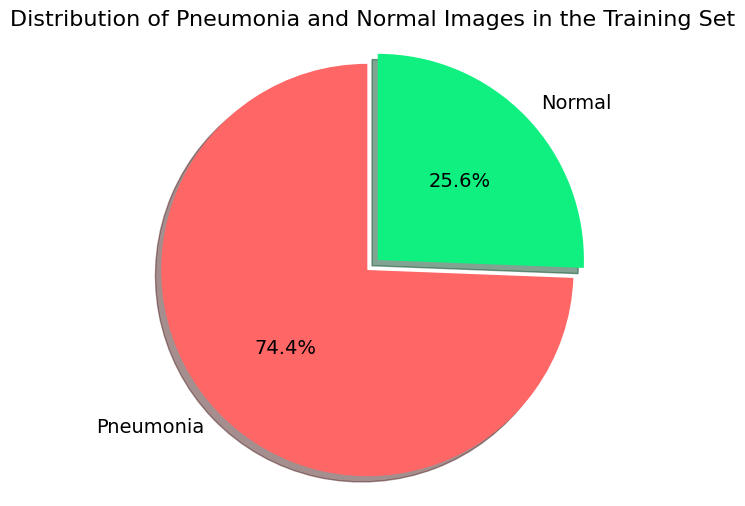

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt

pneumonia_train_images = glob.glob(train_folder+"/PNEUMONIA/*.jpeg")
normal_train_images = glob.glob(train_folder+"/NORMAL/*.jpeg")

# Data for the pie chart
image_counts = np.array([len(pneumonia_train_images), len(normal_train_images)])
labels = ["Pneumonia", "Normal"]
colors = ['#ff6666','#0ff080']
explode = (0.07, 0)

# Check if there are images before creating the pie chart
if image_counts.sum() > 0:
    # Create the pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(image_counts, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, pctdistance=0.55, textprops={'fontsize': 14})

    # Add a title
    plt.title("Distribution of Pneumonia and Normal Images in the Training Set", fontsize=16)

    # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.axis('equal')

    plt.show()
else:
    print("No images found in the training folders to create the pie chart.")

In [ ]:
# Defining function for counting images
def count_images(base_path):
    """Counts the number of images in a folder and its subfolders."""
    image_count = 0
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):  # Add other image extensions if needed
                image_count += 1
    return image_count

# Counting training images
training_folder = os.path.join(base_path, 'train')
train_normal_count = count_images(os.path.join(training_folder, 'NORMAL')) if os.path.exists(os.path.join(training_folder, 'NORMAL')) else 0
train_pneumonia_count = count_images(os.path.join(training_folder, 'PNEUMONIA')) if os.path.exists(os.path.join(training_folder, 'PNEUMONIA')) else 0

# Counting testing images (if 'testing' folder exists)
testing_folder = os.path.join(base_path, 'test')
test_normal_count = count_images(os.path.join(testing_folder, 'NORMAL')) if os.path.exists(os.path.join(testing_folder, 'NORMAL')) else 0
test_pneumonia_count = count_images(os.path.join(testing_folder, 'PNEUMONIA')) if os.path.exists(os.path.join(testing_folder, 'PNEUMONIA')) else 0

# Printing the results
print(f"Training NORMAL Images: {train_normal_count}")
print(f"Training PNEUMONIA Images: {train_pneumonia_count}")
print(f"Testing NORMAL Images: {test_normal_count}")
print(f"Testing PNEUMONIA Images: {test_pneumonia_count}")

# Calculating and print total images
total_train_images = train_normal_count + train_pneumonia_count
total_test_images = test_normal_count + test_pneumonia_count
total_images = total_train_images + total_test_images

print(f"\nTotal training Images: {total_train_images}")
print(f"Total testing Images: {total_test_images}")
print(f"Total Images: {total_images}")

Training NORMAL Images: 1341
Training PNEUMONIA Images: 3895
Testing NORMAL Images: 234
Testing PNEUMONIA Images: 390

Total training Images: 5236
Total testing Images: 624
Total Images: 5860


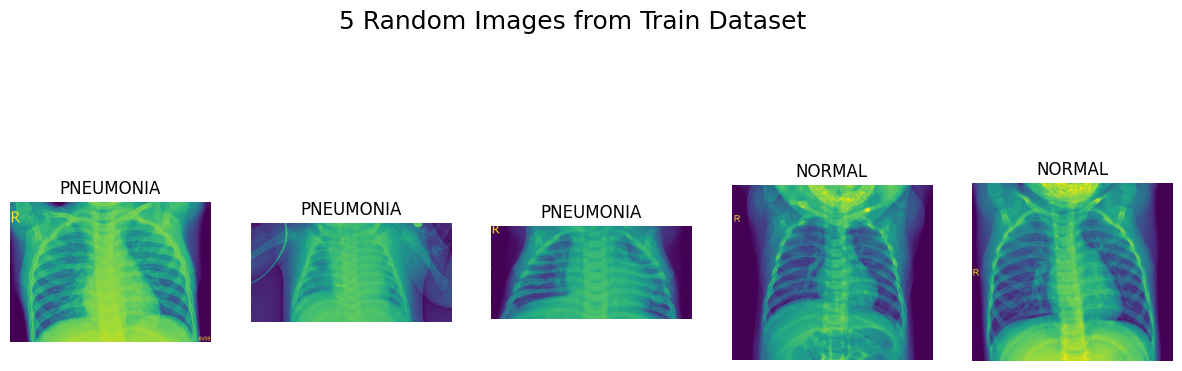

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Defining display random images any labels function for displaying random images with lables from dataset
def display_random_images_any_labels(dataset_path, subfolder, num_images=5):
    """
    Function to display randomly selected images across any labels in a specified subfolder (train/test).

    """
    # Defining Path to the subfolder (train or test)
    subfolder_path = os.path.join(base_path, subfolder)

    # Checking if the subfolder exists
    if not os.path.exists(subfolder_path):
        print(f"Directory not found: {subfolder_path}")
        return

    # Getting all label directories
    labels = [label for label in os.listdir(subfolder_path) if os.path.isdir(os.path.join(subfolder_path, label))]

    # Collecting all images across labels with their corresponding labels
    all_images = []
    for label in labels:
        label_path = os.path.join(subfolder_path, label)
        image_files = [os.path.join(label_path, img) for img in os.listdir(label_path) if os.path.isfile(os.path.join(label_path, img))]
        all_images.extend([(img_path, label) for img_path in image_files])

    # Randomly sampling the specified number of images
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    # Displaying the selected images
    plt.figure(figsize=(15, 5))
    for i, (img_path, label) in enumerate(selected_images):
        img = mpimg.imread(img_path)
        plt.subplot(1, len(selected_images), i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(label)
    plt.suptitle(f"5 Random Images from {subfolder.capitalize()} Dataset", fontsize=18)
    # Adjusting the spacing here
    plt.subplots_adjust(top=0.8)
    plt.show()

dataset_path = '/content/drive/My Drive/Colab Notebooks/chestxray'

# Displaying 5 random images from training
display_random_images_any_labels(dataset_path, 'train', num_images=5)

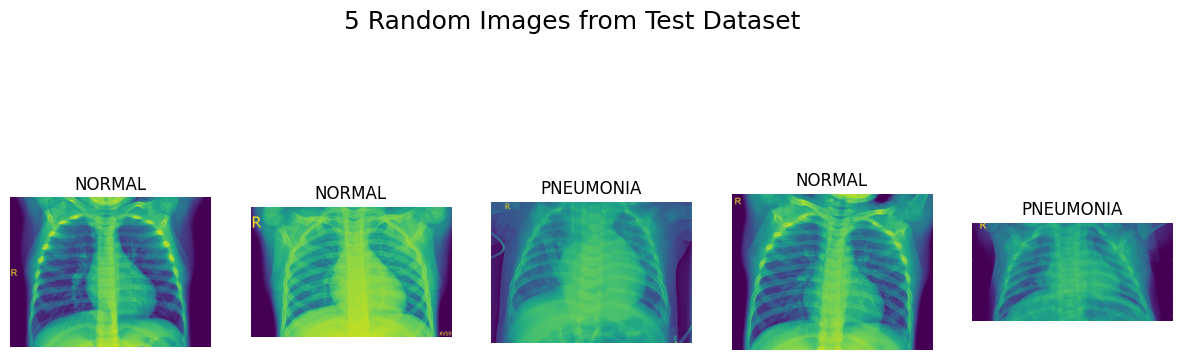

In [ ]:
# Displaying 5 random images from test dataset
display_random_images_any_labels(dataset_path, 'test', num_images=5)

In [ ]:
! ls '/content/drive/My Drive/Colab Notebooks/chestxray/train'

NORMAL	PNEUMONIA


In [ ]:
import cv2
import numpy as np
from tqdm import tqdm # tqdm used for visualizing the progress of loops and iterations

# Defining the directory containing the training dataset
DATADIR = '/content/drive/My Drive/Colab Notebooks/chestxray/train'

# Defining the categories for classification
CATEGORIES = ['NORMAL', 'PNEUMONIA']

In [ ]:
IMG_SIZE = 128

def create_training_data():
   # initializing an empty list to store the training data
    training_data = []

    for category in CATEGORIES:
        # Creating the path to the category's directory
        path = os.path.join(DATADIR,category)
        # Assigning a numerical label to the category
        class_num = CATEGORIES.index(category)

        # Iterating over each images file in the directory using tqdm for a process bar
        for img in tqdm(os.listdir(path)):
            try:
              # Reading the image using OpenCV
                img_array = cv2.imread(os.path.join(path,img))
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass
   # Returning the created training data list
    return training_data

In [ ]:
# Creating training data function to load and preprocess the training data
training_data = create_training_data()

100%|██████████| 3895/3895 [02:31<00:00, 25.71it/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths to the dataset
base_dir = '/content/drive/My Drive/Colab Notebooks/chestxray'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Define image dimensions and batch size
img_width, img_height = 128, 128  # Changed to match MobileNetV2 input size
batch_size = 32

# Create an ImageDataGenerator for the training data with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest')

# Create an ImageDataGenerator for the validation and test data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create the training data generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary')

# Create the validation data generator
validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary')

# Create the test data generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False)

Found 5236 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
# Calculate class weights to handle data imbalance
from sklearn.utils import class_weight
import numpy as np

# Get the class labels from the training generator
class_labels = train_generator.classes

# Calculate class weights
class_weights = class_weight.compute_class_weight('balanced',
                                                 classes=np.unique(class_labels),
                                                 y=class_labels)
class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9522744220730799), 1: np.float64(0.6721437740693197)}


Initiate InceptionV3

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

# Load the pretrained InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False,
                             input_shape=(img_width, img_height, 3))

# Freeze the base model
base_model.trainable = False

# Create a new model on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'), # Added a new dense layer with reduced units
    layers.Dropout(0.35), # Increased dropout
    layers.Dense(16, activation='relu'), # Added a new dense layer with reduced units
    layers.Dropout(0.35), # Increased dropout
    layers.Dense(8, activation='relu'), # Added a new dense layer with reduced units
    layers.Dropout(0.35), # Increased dropout
    layers.Dense(1, activation='sigmoid') # Changed to 1 unit with sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2, 2, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,869,025 (83.42 MB)

 Trainable params: 66,241 (258.75 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the directory where you want to save the best model
save_dir = '/content/drive/My Drive/Colab Notebooks/chestxray'

# Create the directory if it doesn't exist
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Define the checkpoint file path
checkpoint_path = os.path.join(save_dir, 'In102.h5')

# Define the ModelCheckpoint callback
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',  # Monitor validation accuracy
    save_best_only=True,     # Save only the best model
    mode='max',              # Save when validation accuracy is maximized
    verbose=1                # Print messages when a model is saved
)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=20,
    class_weight=class_weights,
    callbacks=[checkpoint_callback] # Add the callback here
)

In [ ]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/chestxray/In102.h5', compile=False)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Define the directory where you want to save the model
save_dir = '/content/drive/My Drive/Colab Notebooks/chestxray'

# Create the directory if it doesn't exist
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the model
model_path = os.path.join(save_dir, 'In102.h5')
model.save(model_path)
print(f"Model saved to: {model_path}")

Model saved to: /content/drive/My Drive/Colab Notebooks/chestxray/In102.h5


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get the true labels and predicted labels
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

# Print the classification report
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

# Print the confusion matrix
print(confusion_matrix(y_true, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 145s 7s/step
              precision    recall  f1-score   support

      NORMAL       0.78      0.78      0.78       234
   PNEUMONIA       0.87      0.87      0.87       390

    accuracy                           0.84       624
   macro avg       0.83      0.82      0.83       624
weighted avg       0.84      0.84      0.84       624

[[182  52]
 [ 50 340]]


In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_generator, verbose=2)
print(f'Test accuracy: {test_acc}')

20/20 - 18s - 885ms/step - accuracy: 0.8365 - loss: 0.3916
Test accuracy: 0.8365384340286255


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import tensorflow as tf


# Load the EfficientNetB0 model
model_efn = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/chestxray/In102.h5', compile=False)

cm_efn = confusion_matrix(y_true, y_pred)

# Extracting values from the confusion matrix based on PNEUMONIA (class 1) as the positive class
tn_efn, fp_efn, fn_efn, tp_efn = cm_efn.ravel()

# To avoid division by zero
precision_efn = tp_efn / (tp_efn + fp_efn) if (tp_efn + fp_efn) > 0 else 0
recall_efn = tp_efn / (tp_efn + fn_efn) if (tp_efn + fn_efn) > 0 else 0
f1_score_efn = 2 * (precision_efn * recall_efn) / (precision_efn + recall_efn) if (precision_efn + recall_efn) > 0 else 0

# Print the metrics in percentage format
print("EfficientNetB0 Model Metrics (PNEUMONIA as positive class):")
print(f"Precision: {precision_efn * 100:.2f}%")
print(f"Recall: {recall_efn * 100:.2f}%")
print(f"F1-Score: {f1_score_efn * 100:.2f}%")

EfficientNetB0 Model Metrics (PNEUMONIA as positive class):
Precision: 86.73%
Recall: 87.18%
F1-Score: 86.96%


### Initiate DenseNet201

In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras import layers, models

# Define image dimensions
img_width, img_height = 128, 128

# Load the pre-trained DenseNet201 model, excluding the top classification layer
base_model_densenet = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Freeze the layers of the base model
base_model_densenet.trainable = False

# Create a new model on top of the base model
model_densenet = models.Sequential([
    base_model_densenet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'), # Reduced units as per previous request
    layers.Dropout(0.4),
    layers.Dense(16, activation='relu'), # Reduced units as per previous request
    layers.Dropout(0.4),
    layers.Dense(8, activation='relu'), # Reduced units as per previous request
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

# Compile the model
model_densenet.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# Print the model summary
model_densenet.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 4, 4, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        61,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,384,129 (70.13 MB)

 Trainable params: 62,145 (242.75 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the directory where you want to save the best model
save_dir = '/content/drive/My Drive/Colab Notebooks/chestxray'

# Create the directory if it doesn't exist
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Define the checkpoint file path
checkpoint_path_densenet = os.path.join(save_dir, 'DenseNet201_best_model.h5')

# Define the ModelCheckpoint callback
checkpoint_callback_densenet = ModelCheckpoint(
    filepath=checkpoint_path_densenet,
    monitor='val_accuracy',  # Monitor validation accuracy
    save_best_only=True,     # Save only the best model
    mode='max',              # Save when validation accuracy is maximized
    verbose=1                # Print messages when a model is saved
)

# Train the DenseNet201 model
history_densenet = model_densenet.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=20, # You can adjust the number of epochs
    class_weight=class_weights, # Use the class weights calculated earlier
    callbacks=[checkpoint_callback_densenet] # Add the callback here
)

print(f"Best DenseNet201 model will be saved to: {checkpoint_path_densenet}")

In [ ]:
# Define the directory where you want to save the DenseNet201 model
save_dir_densenet = '/content/drive/My Drive/Colab Notebooks/chestxray'

# Create the directory if it doesn't exist
import os
if not os.path.exists(save_dir_densenet):
    os.makedirs(save_dir_densenet)

# Define the model file path (this is the same as checkpoint_path_densenet)
densenet_model_path = os.path.join(save_dir_densenet, 'DenseNet201_best_model.h5')

print(f"DenseNet201 model loaded from: {densenet_model_path}")

DenseNet201 model loaded from: /content/drive/My Drive/Colab Notebooks/chestxray/DenseNet201_best_model.h5


In [ ]:
# Load the best DenseNet201 model
best_densenet_model = tf.keras.models.load_model(densenet_model_path, compile=False)

# Evaluate the model on the test set
best_densenet_model.compile(optimizer='adam',
                            loss='binary_crossentropy',
                            metrics=['accuracy'])

test_loss_densenet, test_acc_densenet = best_densenet_model.evaluate(test_generator, verbose=2)
print(f'DenseNet201 Test accuracy: {test_acc_densenet * 100:.2f}%')

20/20 - 41s - 2s/step - accuracy: 0.8558 - loss: 0.3901
DenseNet201 Test accuracy: 85.58%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get the true labels and predicted labels for DenseNet201
y_true_densenet = test_generator.classes
y_pred_probs_densenet = best_densenet_model.predict(test_generator)
y_pred_densenet = (y_pred_probs_densenet > 0.5).astype(int).reshape(-1)

# Print the classification report for DenseNet201
print("DenseNet201 Classification Report:")
print(classification_report(y_true_densenet, y_pred_densenet, target_names=['NORMAL', 'PNEUMONIA']))

# Print the confusion matrix for DenseNet201
print("DenseNet201 Confusion Matrix:")
print(confusion_matrix(y_true_densenet, y_pred_densenet))

20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step
DenseNet201 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.71      0.79       234
   PNEUMONIA       0.84      0.95      0.89       390

    accuracy                           0.86       624
   macro avg       0.86      0.83      0.84       624
weighted avg       0.86      0.86      0.85       624

DenseNet201 Confusion Matrix:
[[165  69]
 [ 21 369]]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from IPython.display import display, Markdown

# Calculate confusion matrix for DenseNet201
cm_densenet = confusion_matrix(y_true_densenet, y_pred_densenet)

# Extracting values from the confusion matrix based on PNEUMONIA (class 1) as the positive class
tn_densenet, fp_densenet, fn_densenet, tp_densenet = cm_densenet.ravel()

# Calculate metrics for DenseNet201
accuracy_densenet = accuracy_score(y_true_densenet, y_pred_densenet)
precision_densenet = precision_score(y_true_densenet, y_pred_densenet)
recall_densenet = recall_score(y_true_densenet, y_pred_densenet)
f1_score_densenet = f1_score(y_true_densenet, y_pred_densenet)

data_densenet = {
    'Metric': ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'],
    'DenseNet201 Model': [accuracy_densenet * 100, precision_densenet * 100, recall_densenet * 100, f1_score_densenet * 100]
}

df_densenet_metrics = pd.DataFrame(data_densenet)

# Format metrics to two decimal places
for col in df_densenet_metrics.columns[1:]:
    df_densenet_metrics[col] = df_densenet_metrics[col].map('{:.2f}'.format)


display(Markdown("### DenseNet201 Model Performance Metrics"))
styled_df_densenet_metrics = df_densenet_metrics.style.set_table_styles([
    {'selector': 'thead th',
     'props': [('background-color', 'lightgrey'), ('color', 'black'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'tbody td',
     'props': [('border-top', '1px solid black'), ('border-bottom', '1px solid black'),
               ('text-align', 'center'), ('padding', '5px')]},
    {'selector': 'table',
     'props': [('border-collapse', 'collapse'), ('width', '50%')]}
]).set_properties(**{'font-size': '12px', 'font-weight': 'bold'})

styled_df_densenet_metrics = styled_df_densenet_metrics.hide(axis="index")
display(styled_df_densenet_metrics)

### DenseNet201 Model Performance Metrics

Metric,DenseNet201 Model
Accuracy (%),85.58
Precision (%),84.25
Recall (%),94.62
F1-Score (%),89.13


Ensemble model: InceptionV3 + DensenNet201


In [ ]:
import tensorflow as tf

# Load your trained models; update the paths as necessary
model_inception = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/chestxray/In102.h5', compile=False)
model_densenet = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/chestxray/DenseNet201_best_model.h5', compile=False)
model_inception._name = 'inception'
model_densenet._name = 'DenseNet201'

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3, DenseNet201
from tensorflow.keras import layers, models, Input
from tensorflow.keras import Model
from tensorflow.keras.layers import Average

# Define image dimensions (should match the input size used for training)
# Adjusted to match the input size used for training in previous cells
img_width, img_height = 128, 128

# Define input layer for the ensemble model
input_layer = Input(shape=(img_width, img_height, 3), name='ensemble_input_layer')

# Define InceptionV3 branch within the ensemble architecture
# Load the base model without the top classification layer
inception_base = InceptionV3(weights='imagenet', include_top=False, input_tensor=input_layer, pooling=None, name='ensemble_inception_base')
# Keep base layers frozen initially (can unfreeze later for fine-tuning)
inception_base.trainable = False

x_inception = inception_base.output
x_inception = layers.GlobalAveragePooling2D(name='ensemble_inception_avg_pool')(x_inception)
# Added a Dense layer to the InceptionV3 branch
x_inception = layers.Dense(32, activation='relu', name='ensemble_inception_dense')(x_inception)
x_inception = layers.Dropout(0.4, name='ensemble_inception_dropout')(x_inception)
output_inception = layers.Dense(1, activation='sigmoid', name='ensemble_inception_output')(x_inception)

# Define DenseNet201 branch within the ensemble architecture
# Load the base model without the top classification layer
densenet_base = DenseNet201(weights='imagenet', include_top=False, input_tensor=input_layer, pooling=None, name='ensemble_densenet_base')
# Keep base layers frozen initially (can unfreeze later for fine-tuning)
densenet_base.trainable = False

x_densenet = densenet_base.output
x_densenet = layers.GlobalAveragePooling2D(name='ensemble_densenet_avg_pool')(x_densenet)
# Added a Dense layer to the DenseNet201 branch
x_densenet = layers.Dense(16, activation='relu', name='ensemble_densenet_dense')(x_densenet)
x_densenet = layers.Dropout(0.4, name='ensemble_densenet_dropout')(x_densenet)
output_densenet = layers.Dense(1, activation='sigmoid', name='ensemble_densenet_output')(x_densenet)


# Average the outputs of the branches
average_output = Average(name='ensemble_average')([output_densenet, output_inception])

# Build the ensemble model
ensemble_model = Model(inputs=input_layer, outputs=average_output, name='ensemble_model_architecture')

# Load the trained weights into the corresponding layers of the ensemble model
# Load the trained individual models again to access their weights
trained_inception_model = None
trained_densenet_model = None

try:
     trained_inception_model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/chestxray/In102.h5', compile=False)
     trained_densenet_model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/chestxray/DenseNet201_best_model.h5', compile=False)
     print("Saved individual trained models loaded successfully for weight transfer.")
except Exception as e:
    print(f"Error loading saved individual trained models: {e}")
    # Handle error loading models if necessary

# Load weights into the corresponding layers of the ensemble model
print("Attempting to load weights into ensemble model...")
if trained_densenet_model:
    for layer in trained_densenet_model.layers:
        try:
            # Find the corresponding layer in the ensemble model by name
            ensemble_layer = ensemble_model.get_layer(layer.name)
            ensemble_layer.set_weights(layer.get_weights())
            # print(f"Loaded weights for layer: {layer.name} into ensemble model.") # Uncomment for detailed logging
        except ValueError:
            # This layer might not exist in the ensemble model architecture (e.g., the original InputLayer or the final Dense layer if built differently)
            pass
        except Exception as e:
            print(f"Could not load weights for layer {layer.name}: {e}")
else:
    print("DenseNet201 model not loaded, skipping weight transfer.")


if trained_inception_model:
    for layer in trained_inception_model.layers:
        try:
            # Find the corresponding layer in the ensemble model by name
            ensemble_layer = ensemble_model.get_layer(layer.name)
            ensemble_layer.set_weights(layer.get_weights())
            # print(f"Loaded weights for layer: {layer.name} into ensemble model.") # Uncomment for detailed logging
        except ValueError:
             # This layer might not exist in the ensemble model architecture
            pass
        except Exception as e:
            print(f"Could not load weights for layer {layer.name}: {e}")
else:
    print("InceptionV3 model not loaded, skipping weight transfer.")

print("Trained weights loading process completed.")

# Compile the ensemble model
ensemble_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # use binary_crossentropy for 2 classes
    metrics=['accuracy']
)

ensemble_model.summary()

print("Ensemble model built, weights loaded, and compiled.")

Saved individual trained models loaded successfully for weight transfer.
Attempting to load weights into ensemble model...
Trained weights loading process completed.


Model: "ensemble_model_architecture"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ensemble_input_lay… │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 134, 134,  │          0 │ ensemble_input_l… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 40,221,122 (153.43 MB)

 Trainable params: 96,354 (376.38 KB)

 Non-trainable params: 40,124,768 (153.06 MB)

Ensemble model built, weights loaded, and compiled.


In [ ]:
ensemble_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # use binary_crossentropy for 2 classes
    metrics=['accuracy']
)

In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the directory where you want to save the best ensemble model
save_dir = '/content/drive/My Drive/Colab Notebooks/chestxray'

# Create the directory if it doesn't exist
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Define the checkpoint file path
checkpoint_path = os.path.join(save_dir, 'en201.h5')

# Define the ModelCheckpoint callback
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',  # Monitor validation accuracy
    save_best_only=True,     # Save only the best model
    mode='max',              # Save when validation accuracy is maximized
    verbose=1                # Print messages when a model is saved
)

ensemble_model.fit(train_generator, epochs=20, validation_data=validation_generator, callbacks=[checkpoint_callback])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7615 - loss: 0.4081
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /content/drive/My Drive/Colab Notebooks/chestxray/en201.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 420s 2s/step - accuracy: 0.7616 - loss: 0.4077 - val_accuracy: 0.5000 - val_loss: 0.5977
Epoch 2/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7794 - loss: 0.3073
Epoch 2: val_accuracy improved from 0.50000 to 0.68750, saving model to /content/drive/My Drive/Colab Notebooks/chestxray/en201.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.7796 - loss: 0.3072 - val_accuracy: 0.6875 - val_loss: 0.3663
Epoch 3/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8868 - loss: 0.2434
Epoch 3: val_accuracy improved from 0.68750 to 0.87500, saving model to /content/drive/My Drive/Colab Notebooks/chestxray/en201.h5


164/164 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.8868 - loss: 0.2434 - val_accuracy: 0.8750 - val_loss: 0.3504
Epoch 4/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9162 - loss: 0.2151
Epoch 4: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9162 - loss: 0.2151 - val_accuracy: 0.6875 - val_loss: 0.3584
Epoch 5/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9160 - loss: 0.2086
Epoch 5: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.9160 - loss: 0.2086 - val_accuracy: 0.6250 - val_loss: 0.5177
Epoch 6/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9221 - loss: 0.1933
Epoch 6: val_accuracy did not improve from 0.87500
164/164 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.9221 - loss: 0.1932 - val_accuracy: 0.6875 - val_loss: 0.3945
Epoch 7/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9199 - loss: 0.2135
Epoch 7: val_accuracy did not impro

164/164 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.9365 - loss: 0.1790 - val_accuracy: 0.9375 - val_loss: 0.2959
Epoch 12/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9407 - loss: 0.1675
Epoch 12: val_accuracy did not improve from 0.93750
164/164 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.9407 - loss: 0.1676 - val_accuracy: 0.6250 - val_loss: 0.5669
Epoch 13/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9365 - loss: 0.1748
Epoch 13: val_accuracy did not improve from 0.93750
164/164 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9366 - loss: 0.1748 - val_accuracy: 0.8125 - val_loss: 0.3206
Epoch 14/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9370 - loss: 0.1772
Epoch 14: val_accuracy did not improve from 0.93750
164/164 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9370 - loss: 0.1772 - val_accuracy: 0.7500 - val_loss: 0.5346
Epoch 15/20
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9298 - loss: 0.1888
Epoch 15: val_accuracy did n

In [29]:
# For evaluation
ensemble_model.evaluate(test_generator)

# For prediction
preds = ensemble_model.predict(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8477 - loss: 0.4231
20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step


In [ ]:
# Evaluate the ensemble model on the test set
ensemble_loss, ensemble_acc = ensemble_model.evaluate(test_generator, verbose=2)
print(f'Ensemble model test accuracy: {ensemble_acc * 100:.2f}%')

In [31]:
# Define the directory where you want to save the ensemble model
save_dir = '/content/drive/My Drive/Colab Notebooks/chestxray'

# Create the directory if it doesn't exist
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the ensemble model
ensemble_model_path = os.path.join(save_dir, '/content/drive/MyDrive/Colab Notebooks/chestxray/en201.h5')
ensemble_model.save(ensemble_model_path)
print(f"Ensemble model saved to: {ensemble_model_path}")

Ensemble model saved to: /content/drive/MyDrive/Colab Notebooks/chestxray/en201.h5


In [ ]:
ensemble_model = tf.keras.models.load_model('/content/drive/MyDrive/Colab Notebooks/chestxray/en201.h5', compile=False)
ensemble_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

20/20 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step
[[184  50]
 [ 24 366]]


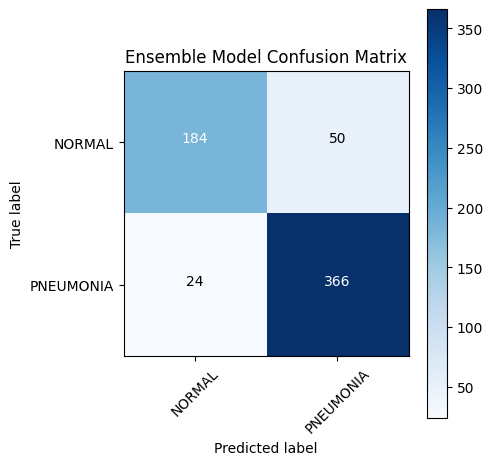

In [33]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Get the true labels from the test generator
y_true_ensemble = test_generator.classes

# Get the predicted labels from the ensemble model
y_pred_probs_ensemble = ensemble_model.predict(test_generator)
y_pred_ensemble = (y_pred_probs_ensemble > 0.5).astype(int).reshape(-1)

# Calculate the confusion matrix
cm_ensemble = confusion_matrix(y_true_ensemble, y_pred_ensemble)

# Define class labels for the plot
cm_plot_labels = ['NORMAL', 'PNEUMONIA']

# Plot the confusion matrix using the function defined earlier
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

plt.figure(figsize=(5, 5))
plot_confusion_matrix(cm_ensemble, cm_plot_labels, title='Ensemble Model Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import tensorflow as tf

# Import the custom layer class
from tensorflow.keras.layers import Layer

# Define the custom layer again so Keras can recognize it
class EnsembleAverage(Layer):
    def __init__(self, **kwargs):
        super(EnsembleAverage, self).__init__(**kwargs)

    def call(self, inputs):
        # Inputs should be a list of tensors, one from each model
        return tf.keras.layers.Average()(inputs)


# Load the ensemble model with custom objects
model_ensemble = tf.keras.models.load_model(
    '/content/drive/MyDrive/Colab Notebooks/chestxray/en201.h5',
    compile=False,
    custom_objects={'EnsembleAverage': EnsembleAverage}
)

# The rest of the code to calculate and print metrics
y_true_ensemble = test_generator.classes
y_pred_probs_ensemble = model_ensemble.predict(test_generator)
y_pred_ensemble = (y_pred_probs_ensemble > 0.5).astype(int).reshape(-1)


cm_ensemble = confusion_matrix(y_true_ensemble, y_pred_ensemble)

# Extracting values from the confusion matrix based on PNEUMONIA (class 1) as the positive class
tn_ensemble, fp_ensemble, fn_ensemble, tp_ensemble = cm_ensemble.ravel()

# Calculate accuracy
accuracy_ensemble = accuracy_score(y_true_ensemble, y_pred_ensemble)


# To avoid division by zero
precision_ensemble = tp_ensemble / (tp_ensemble + fp_ensemble) if (tp_ensemble + fp_ensemble) > 0 else 0
recall_ensemble = tp_ensemble / (tp_ensemble + fn_ensemble) if (tp_ensemble + fn_ensemble) > 0 else 0
f1_score_ensemble = 2 * (precision_ensemble * recall_ensemble) / (precision_ensemble + recall_ensemble) if (precision_ensemble + recall_ensemble) > 0 else 0

# Print the metrics in percentage format
print("Ensemble Model Metrics (PNEUMONIA as positive class):")
print(f"Accuracy: {accuracy_ensemble * 100:.2f}%")
print(f"Precision: {precision_ensemble * 100:.2f}%")
print(f"Recall: {recall_ensemble * 100:.2f}%")
print(f"F1-Score: {f1_score_ensemble * 100:.2f}%")

In [35]:
import pandas as pd
from IPython.display import display, Markdown

data = {
    'Metric': ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'],
    'Ensemble Model': [ensemble_acc * 100, precision_ensemble * 100, recall_ensemble * 100, f1_score_ensemble * 100]
}

df_ensemble_metrics = pd.DataFrame(data)

# Format metrics to two decimal places
for col in df_ensemble_metrics.columns[1:]:
    df_ensemble_metrics[col] = df_ensemble_metrics[col].map('{:.2f}'.format)


display(Markdown("### Ensemble Model Performance Metrics"))
styled_df_ensemble_metrics = df_ensemble_metrics.style.set_table_styles([
    {'selector': 'thead th',
     'props': [('background-color', 'lightgrey'), ('color', 'black'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'tbody td',
     'props': [('border-top', '1px solid black'), ('border-bottom', '1px solid black'),
               ('text-align', 'center'), ('padding', '5px')]},
    {'selector': 'table',
     'props': [('border-collapse', 'collapse'), ('width', '50%')]}
]).set_properties(**{'font-size': '12px', 'font-weight': 'bold'})

styled_df_ensemble_metrics = styled_df_ensemble_metrics.hide(axis="index")
display(styled_df_ensemble_metrics)

### Ensemble Model Performance Metrics

Metric,Ensemble Model
Accuracy (%),88.14
Precision (%),87.98
Recall (%),93.85
F1-Score (%),90.82


In [ ]:
%%shell
jupyter nbconvert --to html "/content/Incepv3+Densenet201 (2).ipynb"

[NbConvertApp] Converting notebook /content/Incepv3+Densenet201 (2).ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('metadata' was unexpected)

Failed validating 'additionalProperties' in stream:

On instance['cells'][33]['outputs'][0]:
{'metadata': {'tags': None},
 'name': 'stderr',
 'output_type': 'stream',
 'text': '/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_...'}
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 1857213 bytes to /content/Incepv3+Densenet201 (2).html
